<img src="../res/logo.jpg" alt="Volcanicus" width="50%">

# Comparing volcanoes

`volcanicus` ships more than one example dataset. This notebook loads all of them and compares them side by side: how much data each one has, how much is missing, and how their radial/temporal profiles look next to each other.

See [tutorial.ipynb](tutorial.ipynb) first if you haven't yet — it covers the `Volcano` API this notebook assumes you already know.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

import volcanicus

names = volcanicus.datasets.available()
names

['copahue', 'etna', 'stromboli']

In [2]:
volcanoes = {name: volcanicus.datasets.load(name) for name in names}
for v in volcanoes.values():
    display(v)

dates,100
missing,2926
registers,799


dates,99
missing,4315
registers,790


dates,100
missing,2823
registers,793


## Missing data, side by side

`missing_report()` returns a `pandas.Series` per volcano; stacking them into a single `DataFrame` makes the gaps easy to compare at a glance.

In [3]:
pd.DataFrame(
    {name: v.missing_report() for name, v in volcanoes.items()}
).T

,n_missing,n_dates,n_dates_with_missing,missing_per_date_min,missing_per_date_max,missing_per_date_mean,worst_date
copahue,2926,100,100,4,86,29.26,2014-03-15 00:00:00
etna,4315,99,99,3,481,43.585859,2023-08-18 00:00:00
stromboli,2823,100,100,4,142,28.23,2024-07-28 00:00:00


## Radial profiles, side by side

One `radial_profile()` plot per volcano, sharing the y-axis so the residual scales are directly comparable.

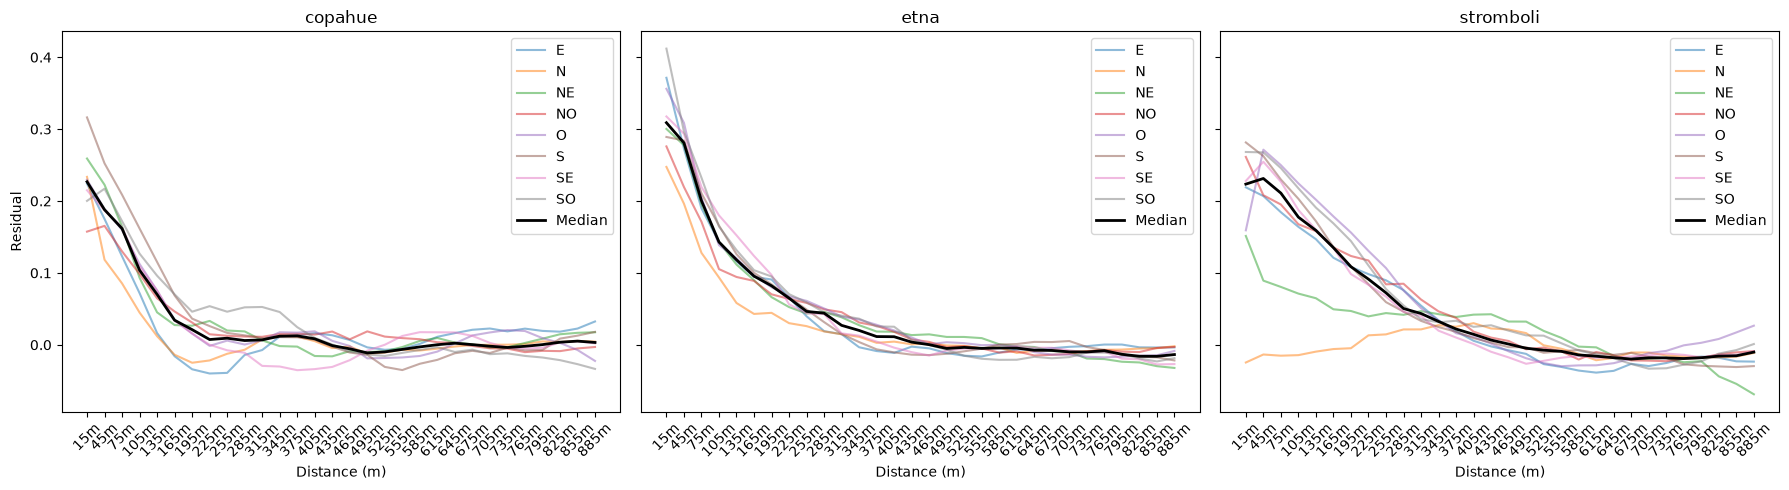

In [4]:
fig, axes = plt.subplots(1, len(volcanoes), figsize=(6 * len(volcanoes), 5), sharey=True)

for ax, (name, v) in zip(axes, volcanoes.items()):
    v.plot.radial_profile(ax=ax)
    ax.set_title(name)

fig.tight_layout()

## Radial profiles, overlaid

`directions=False` turns off the per-direction lines (the same way `median=False` turns off the aggregate one), leaving just each volcano's median curve — which is what makes overlaying several volcanoes on one axis actually readable.

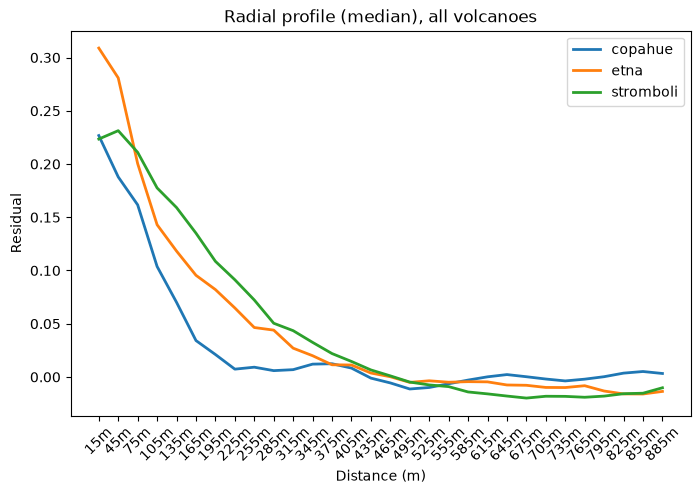

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for color, (name, v) in zip(colors, volcanoes.items()):
    v.plot.radial_profile(
        ax=ax, directions=False, median_kwds={"color": color, "label": name}
    )

ax.set_title("Radial profile (median), all volcanoes")
ax.legend()

## Temporal profiles, side by side

Same idea for `temporal_profile()` — note each volcano covers a different date range.

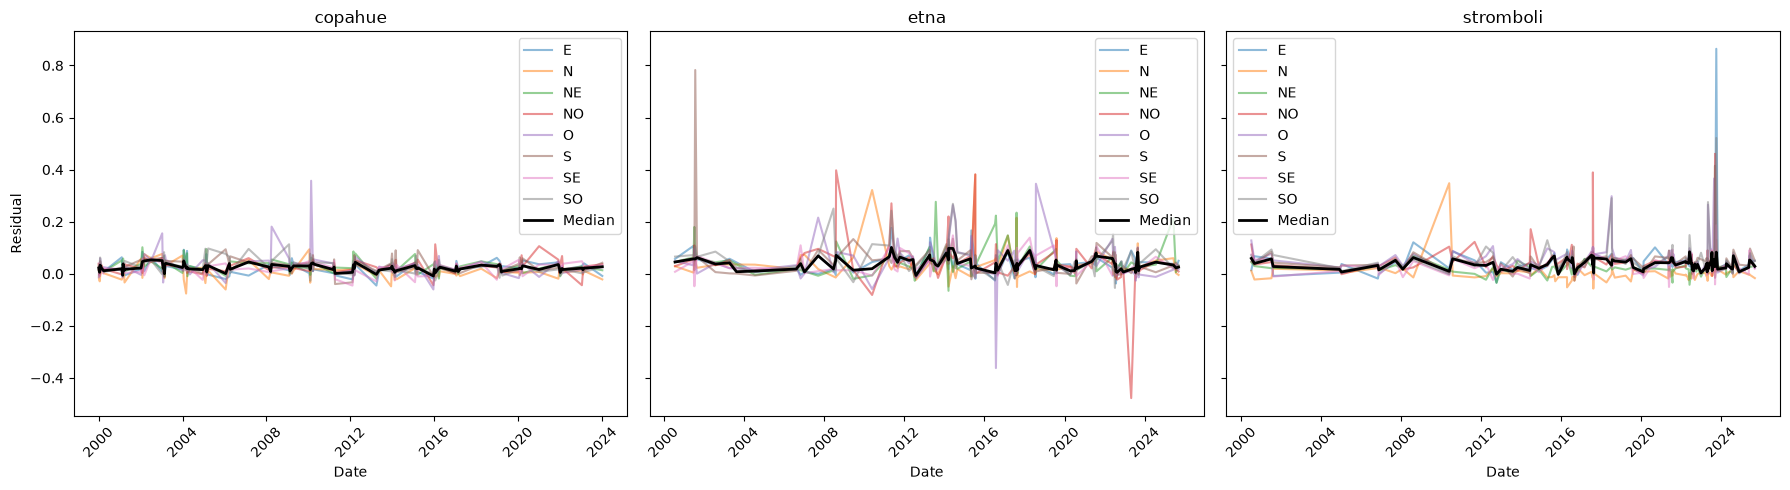

In [6]:
fig, axes = plt.subplots(1, len(volcanoes), figsize=(6 * len(volcanoes), 5), sharey=True)

for ax, (name, v) in zip(axes, volcanoes.items()):
    v.plot.temporal_profile(ax=ax)
    ax.set_title(name)

fig.tight_layout()

## Mean residual per direction, side by side

`.stats.mean(groupby="direction")` reduced to a single number per direction (averaged across distance bins too), one column per volcano.

In [7]:
pd.DataFrame(
    {
        name: v.stats.mean(groupby="direction").mean(axis=1)
        for name, v in volcanoes.items()
    }
)

,copahue,etna,stromboli
direction,,,
E,0.023688,0.043338,0.038524
N,0.013923,0.027976,-0.001620
NE,0.030679,0.043851,0.023061
NO,0.027322,0.040470,0.050504
O,0.028624,0.049781,0.057219
S,0.036701,0.042947,0.047288
SE,0.022276,0.045865,0.043353
SO,0.033207,0.050456,0.058145


## Next steps

- [tutorial.ipynb](tutorial.ipynb) for the full `Volcano` API walkthrough.
- [README.md](../README.md) for installation and a quick reference.
